# La peste no nació en las ciudades

Uno de cada tres. Esa fue la huella de la peste en cuatro cementerios junto al lago Baikal, en Siberia. Pero no hablamos de una ciudad medieval ni de una aldea de granjeros: hablamos de cazadores-recolectores, gente que se movía con las estaciones, hace **5.500 años**.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Lethal plague outbreaks in Lake Baikal hunter-gatherers 5,500 years ago* — Macleod et al., **Nature** (2026)
**DOI:** [10.1038/s41586-026-10540-5](https://doi.org/10.1038/s41586-026-10540-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-17-peste-baikal-cazadores/notebook.ipynb)

**Video:** _Pendiente_

## Lo que se creía

Durante décadas, la historia fue así: la peste necesita aglomeración. Ciudades, graneros, ratas, gente apretada. Por eso se pensaba que sus primeros brotes letales llegaron con la agricultura del Neolítico europeo, cuando los pueblos se volvieron densos.

El equipo extrajo ADN antiguo de restos humanos en cuatro cementerios de cazadores-recolectores cerca del lago Baikal y los rastreó buscando *Yersinia pestis*, la bacteria de la peste. Lo que encontraron en esos huesos pone esa historia en duda.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
EDAD_ADULTEZ = 18           # umbral de subadulto (años)
BANDA_NINOS = (8, 12)       # "older child": el grupo que más aparece
COLOR_DATOS = '#2563EB'     # azul CaM
COLOR_ALERTA = '#DC2626'    # rojo — la cifra que impacta
COLOR_REFERENCIA = '#D97706'  # ámbar — umbrales
COLOR_SECUNDARIO = '#059669'  # emerald
COLOR_GRIS = '#BBBBBB'
FUENTE = 'Fuente: Macleod et al. (2026), Nature | Datos: Supplementary Tables (MOESM3)'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
det = pd.read_csv('datos/deteccion_por_cementerio.csv')
vic = pd.read_csv('datos/victimas_plaga.csv')

tot_pos = det['plaga_positivos'].sum()
tot_coh = det['individuos_cohorte'].sum()
tasa_global = 100 * tot_pos / tot_coh

print(f"Cementerios analizados : {len(det)}")
print(f"Individuos en la cohorte: {tot_coh}")
print(f"Positivos a peste       : {tot_pos}")
print(f"Tasa de detección global: {tasa_global:.1f}%  ({tot_pos}/{tot_coh})")
print(f"\nVíctimas con edad estimada: {vic['edad_media'].notna().sum()} de {len(vic)}")
edades = vic['edad_media'].dropna()
print(f"Edad al morir — mediana {edades.median():.1f}, media {edades.mean():.1f} años")
print(f"  IQR: {edades.quantile(.25):.0f}–{edades.quantile(.75):.0f} años | rango: {edades.min():.1f}–{edades.max():.1f}")

Cementerios analizados : 4
Individuos en la cohorte: 46
Positivos a peste       : 18
Tasa de detección global: 39.1%  (18/46)

Víctimas con edad estimada: 17 de 18
Edad al morir — mediana 14.5, media 18.1 años
  IQR: 10–25 años | rango: 4.5–42.5


## La cifra

39%.

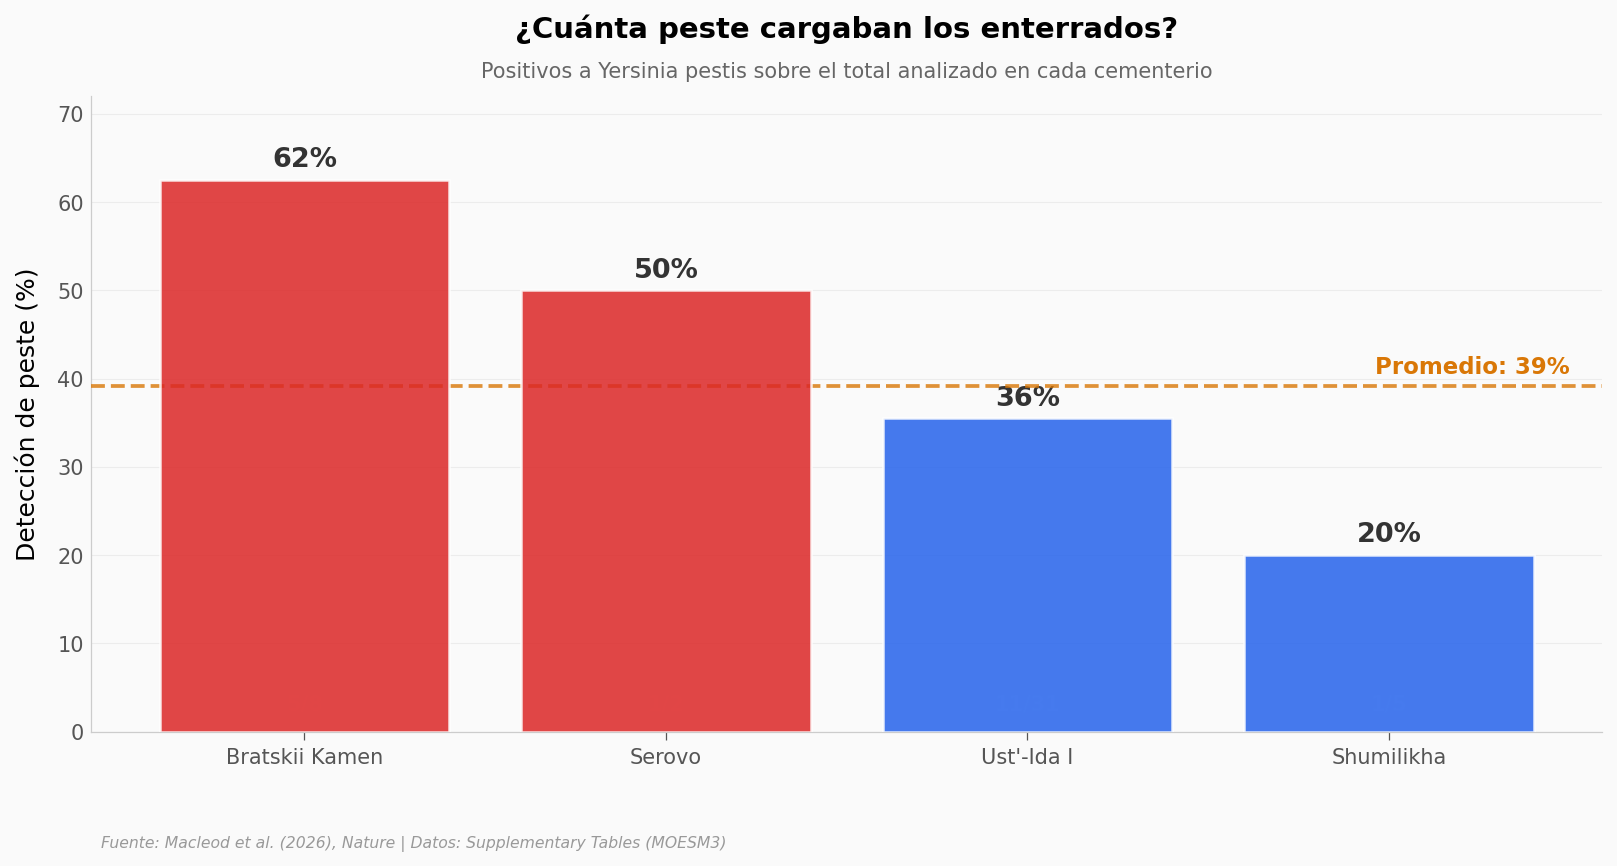

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

det_ord = det.sort_values('tasa_deteccion_pct', ascending=False).reset_index(drop=True)
colores = [COLOR_ALERTA if t >= tasa_global else COLOR_DATOS for t in det_ord['tasa_deteccion_pct']]
barras = ax.bar(det_ord['cementerio'], det_ord['tasa_deteccion_pct'],
                color=colores, alpha=0.85, edgecolor='white', linewidth=1.2, zorder=5)

# Etiqueta de valor + tamaño de muestra sobre cada barra
for i, row in det_ord.iterrows():
    ax.text(i, row['tasa_deteccion_pct'] + 1.5,
            f"{row['tasa_deteccion_pct']:.0f}%",
            ha='center', fontsize=13, fontweight='bold', color='#333333')
    ax.text(i, 2.5, f"{int(row['plaga_positivos'])}/{int(row['individuos_cohorte'])}",
            ha='center', fontsize=10, color='white', fontweight='bold')

# Línea de la tasa global
ax.axhline(y=tasa_global, color=COLOR_REFERENCIA, linewidth=1.8, linestyle='--', alpha=0.8, zorder=4)
ax.text(len(det_ord) - 0.5, tasa_global + 1.5, f'Promedio: {tasa_global:.0f}%',
        ha='right', fontsize=11, fontweight='bold', color=COLOR_REFERENCIA)

ax.set_title('¿Cuánta peste cargaban los enterrados?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Positivos a Yersinia pestis sobre el total analizado en cada cementerio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Detección de peste (%)')
ax.set_ylim(0, 72)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/deteccion_por_cementerio.png', dpi=200, bbox_inches='tight')
plt.show()

De cada diez personas analizadas en estos cuatro cementerios, casi cuatro llevaban ADN de peste en sus huesos al morir. Ese 39% es la cifra que reporta el paper, y sale exacto: 18 positivos sobre 46 individuos.

Bratskii Kamen se dispara hasta el 62%, pero ahí conviene frenar: son apenas 8 personas analizadas. Con muestras tan chicas, un caso de más o de menos mueve el porcentaje un montón. El número sólido es el global. Y hay un detalle que cambia la lectura: esto es detección en restos enterrados, no la tasa de contagio de la población viva.

## ¿A quién se llevó?

Una cosa es cuántos. Otra es quiénes. Si miramos la edad a la que murió cada víctima, aparece un patrón que cuesta mirar.

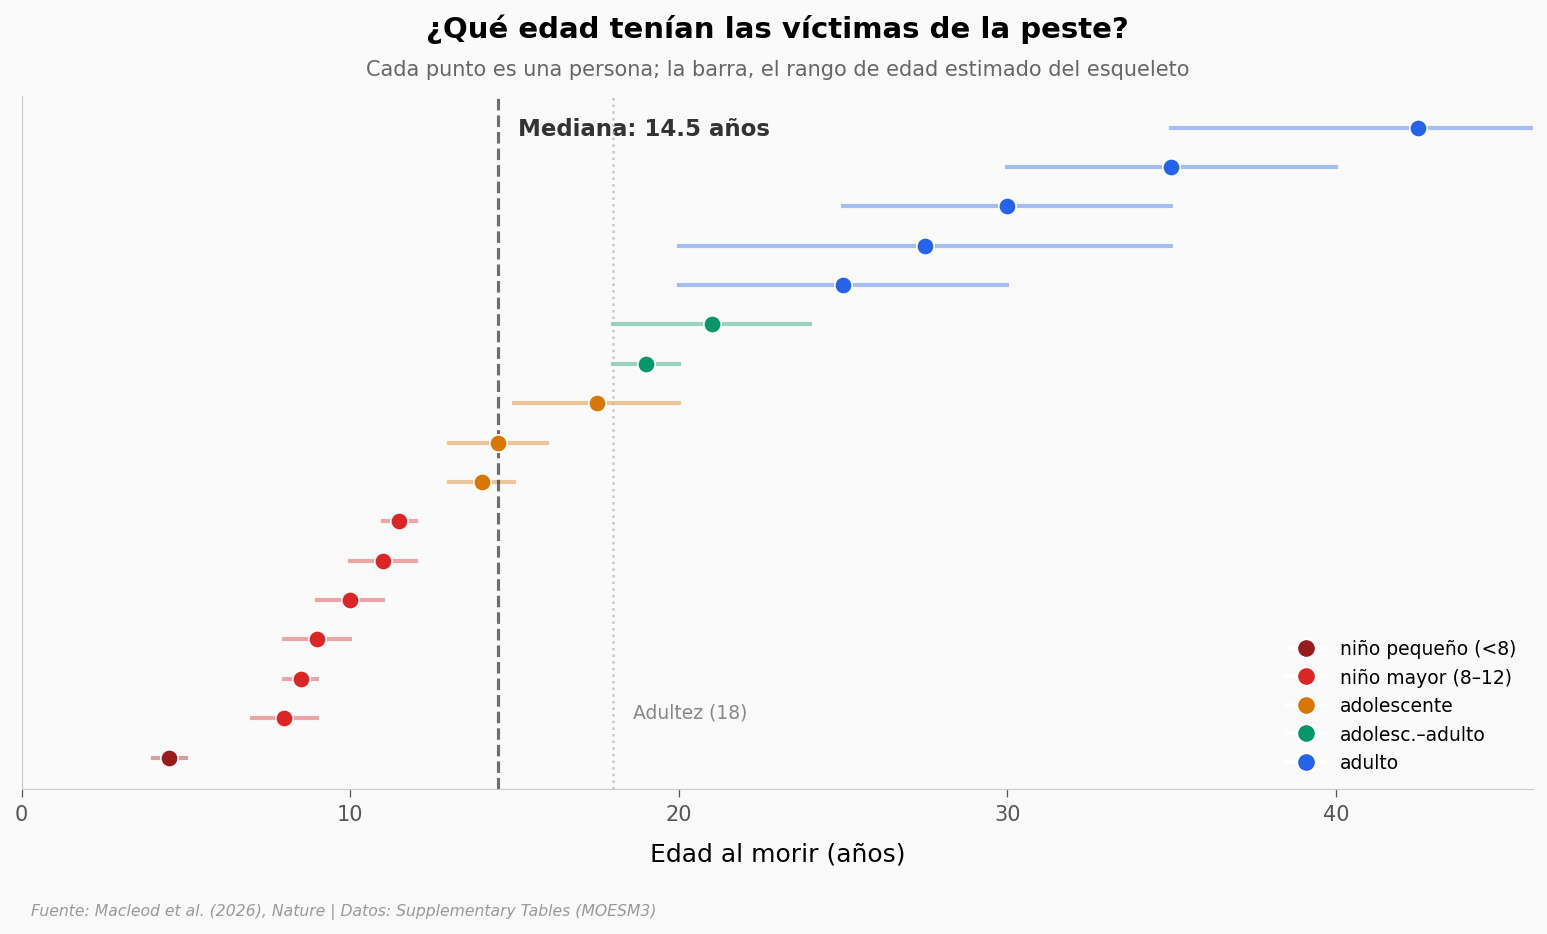

Niños (≤12 años)        : 8 de 18
  de ellos 'niño mayor 8–12': 7 (39% del total)
Subadultos (<18, con edad): 10 de 17 (59%)


In [3]:
fig, ax = plt.subplots(figsize=(13, 6))

# Mapa de color por categoría de edad
cat_color = {
    'young child': '#991B1B',
    'older child': COLOR_ALERTA,
    'adolescent': COLOR_REFERENCIA,
    'adolescent–adult': COLOR_SECUNDARIO,
    'adult': COLOR_DATOS,
}

v = vic.dropna(subset=['edad_media']).sort_values('edad_media').reset_index(drop=True)
for i, row in v.iterrows():
    c = cat_color.get(row['categoria_edad'], COLOR_GRIS)
    # rango de edad estimado (min-max) como línea
    if pd.notna(row['edad_min']) and pd.notna(row['edad_max']):
        ax.plot([row['edad_min'], row['edad_max']], [i, i], color=c, linewidth=2, alpha=0.4, zorder=3)
    ax.scatter(row['edad_media'], i, color=c, s=70, edgecolors='white', linewidths=0.8, zorder=5)

mediana = v['edad_media'].median()
ax.axvline(x=mediana, color='#333333', linewidth=1.5, linestyle='--', alpha=0.7, zorder=4)
ax.text(mediana + 0.6, len(v) - 1.2, f'Mediana: {mediana:.1f} años',
        fontsize=11, fontweight='bold', color='#333333')
ax.axvline(x=EDAD_ADULTEZ, color=COLOR_GRIS, linewidth=1.2, linestyle=':', alpha=0.8, zorder=4)
ax.text(EDAD_ADULTEZ + 0.6, 1.0, 'Adultez (18)', fontsize=9, color='#888888')

# Leyenda inline de categorías (orden etario)
orden = ['young child', 'older child', 'adolescent', 'adolescent–adult', 'adult']
etiqueta = {'young child': 'niño pequeño (<8)', 'older child': 'niño mayor (8–12)',
            'adolescent': 'adolescente', 'adolescent–adult': 'adolesc.–adulto', 'adult': 'adulto'}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cat_color[k],
                      markersize=9, label=etiqueta[k]) for k in orden]
ax.legend(handles=handles, fontsize=9, loc='lower right', framealpha=0.9)

ax.set_title('¿Qué edad tenían las víctimas de la peste?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es una persona; la barra, el rango de edad estimado del esqueleto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Edad al morir (años)')
ax.set_yticks([])
ax.set_xlim(0, 46)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/edades_victimas.png', dpi=200, bbox_inches='tight')
plt.show()

# Conteos para la narrativa
ninos = vic[vic['categoria_edad'].isin(['young child', 'older child'])]
older = vic[vic['categoria_edad'] == 'older child']
subad = v[v['edad_media'] < EDAD_ADULTEZ]
print(f"Niños (≤12 años)        : {len(ninos)} de {len(vic)}")
print(f"  de ellos 'niño mayor 8–12': {len(older)} ({100*len(older)/len(vic):.0f}% del total)")
print(f"Subadultos (<18, con edad): {len(subad)} de {len(v)} ({100*len(subad)/len(v):.0f}%)")

## No fue una vez

Los huesos no solo dicen quién: también dicen cuándo. Las dataciones por radiocarbono reparten a las víctimas en el tiempo, y dibujan dos olas separadas por siglos.

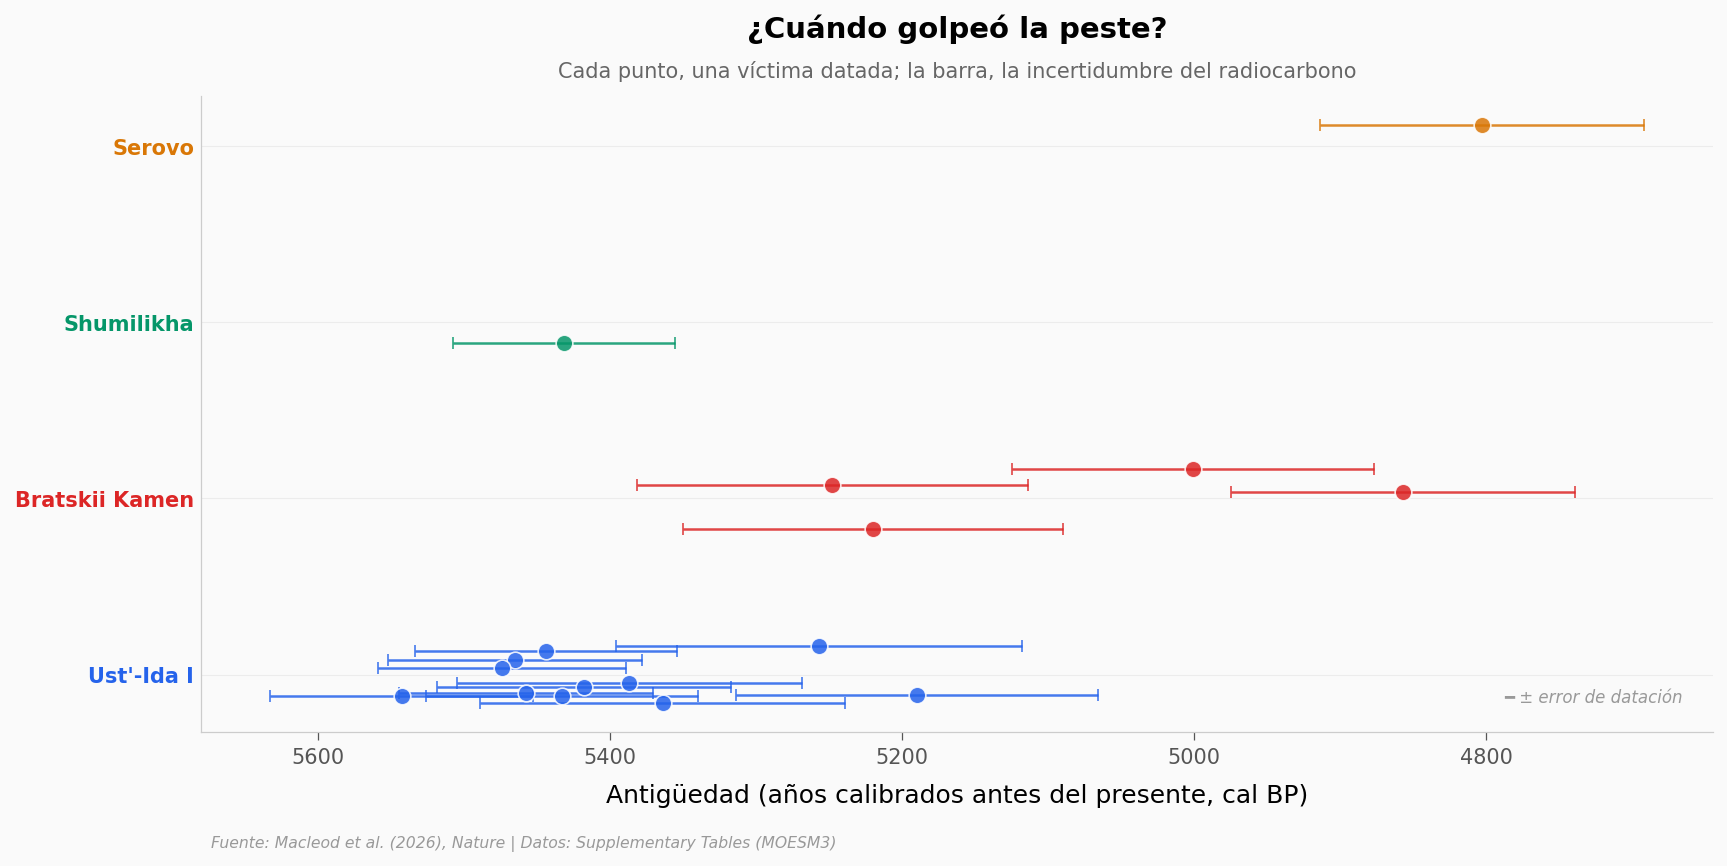

Rango total: 5543–4803 cal BP (740 años de diferencia)
Ust'-Ida I (ola temprana): media 5403 cal BP (n=11)
Bratskii Kamen (ola tardía): media 5082 cal BP (n=4)


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

cem_color = {
    "Ust'-Ida I": COLOR_DATOS,
    'Bratskii Kamen': COLOR_ALERTA,
    'Shumilikha': COLOR_SECUNDARIO,
    'Serovo': COLOR_REFERENCIA,
}
cems = list(cem_color.keys())
ypos = {c: i for i, c in enumerate(cems)}

vt = vic.dropna(subset=['fecha_cal_bp'])
np.random.seed(42)
for _, row in vt.iterrows():
    c = cem_color[row['cementerio']]
    y = ypos[row['cementerio']] + np.random.uniform(-0.18, 0.18)
    err = row['fecha_error'] if pd.notna(row['fecha_error']) else 0
    ax.errorbar(row['fecha_cal_bp'], y, xerr=err, fmt='o', color=c,
                markersize=8, markeredgecolor='white', markeredgewidth=0.8,
                ecolor=c, elinewidth=1.2, capsize=3, alpha=0.85, zorder=5)

ax.set_yticks(range(len(cems)))
ax.set_yticklabels(cems, fontsize=10)
for tick, c in zip(ax.get_yticklabels(), [cem_color[k] for k in cems]):
    tick.set_color(c)
    tick.set_fontweight('bold')

ax.invert_xaxis()  # más antiguo a la izquierda, más reciente a la derecha
ax.set_title('¿Cuándo golpeó la peste?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto, una víctima datada; la barra, la incertidumbre del radiocarbono',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Antigüedad (años calibrados antes del presente, cal BP)')
ax.text(0.98, 0.04, '━ ± error de datación', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/linea_tiempo.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats temporales para la narrativa
ui = vt[vt['cementerio'] == "Ust'-Ida I"]['fecha_cal_bp']
bk = vt[vt['cementerio'] == 'Bratskii Kamen']['fecha_cal_bp']
print(f"Rango total: {vt['fecha_cal_bp'].max():.0f}–{vt['fecha_cal_bp'].min():.0f} cal BP "
      f"({vt['fecha_cal_bp'].max()-vt['fecha_cal_bp'].min():.0f} años de diferencia)")
print(f"Ust'-Ida I (ola temprana): media {ui.mean():.0f} cal BP (n={len(ui)})")
print(f"Bratskii Kamen (ola tardía): media {bk.mean():.0f} cal BP (n={len(bk)})")

## Morir a los 14

Volvamos a la edad. ¿Qué tan joven es el conjunto de estas víctimas? La distribución completa lo deja claro de un vistazo.

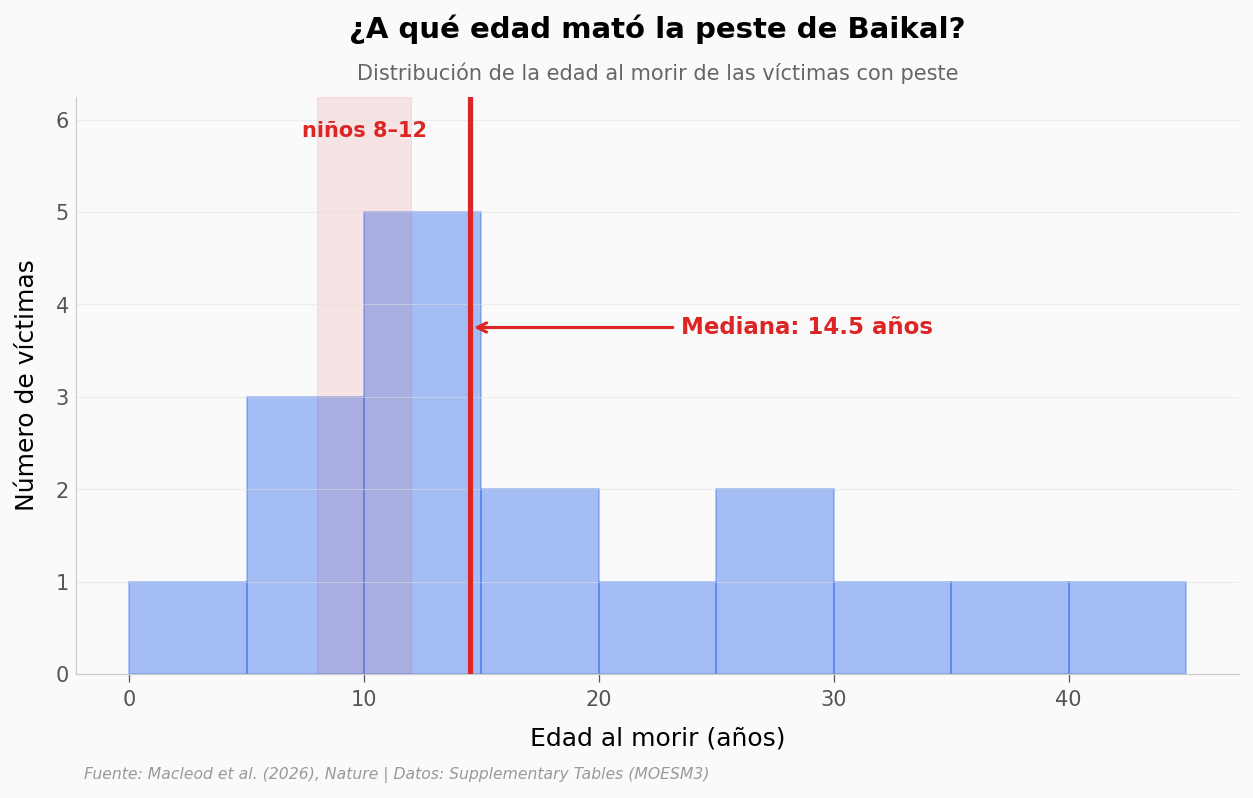

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

edades = vic['edad_media'].dropna().values
bins = np.arange(0, 50, 5)
n, bins_out, patches = ax.hist(edades, bins=bins, color=COLOR_DATOS, alpha=0.4,
                               edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Banda "niño mayor" 8-12
ax.axvspan(BANDA_NINOS[0], BANDA_NINOS[1], color=COLOR_ALERTA, alpha=0.10, zorder=1)
ax.text((BANDA_NINOS[0]+BANDA_NINOS[1])/2, y_max*0.93, 'niños 8–12',
        ha='center', fontsize=10, fontweight='bold', color=COLOR_ALERTA)

mediana = np.median(edades)
ax.axvline(x=mediana, color=COLOR_ALERTA, linewidth=2.5, zorder=6)
ax.annotate(f'Mediana: {mediana:.1f} años', xy=(mediana, y_max*0.6),
            xytext=(mediana + 9, y_max*0.6), fontsize=11, fontweight='bold',
            color=COLOR_ALERTA, va='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_title('¿A qué edad mató la peste de Baikal?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de la edad al morir de las víctimas con peste',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Edad al morir (años)')
ax.set_ylabel('Número de víctimas')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_edad.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La detección de peste es del 39% | ✅ | 18 positivos / 46 individuos = 39,1%. Coincide exacto con el paper. Es detección en restos enterrados, no contagio poblacional. |
| Las víctimas son jóvenes | ✅ | Mediana de edad al morir: 14,5 años (IQR 10–25). 7 de 18 caen en "niño mayor" (8–12). |
| Hubo dos olas separadas en el tiempo | ✅ | Ust'-Ida I se agrupa alrededor de ~5.400 cal BP; Bratskii Kamen alrededor de ~5.100 cal BP. El rango total abarca unos 740 años. |
| Hubo contagio de persona a persona | ⚠️ | El paper lo infiere de pedigríes de parentesco (datos no incluidos aquí). El abstract lo enmarca como *consistente con* transmisión humana, no como prueba. |
| La peste causó muerte aguda en niños | ⚠️ | El paper dice que las infecciones *parecen* haber causado mortalidad aguda, sobre todo en niños de 8 a 11 años. Es un diseño observacional: vemos sobre-representación de niños entre los muertos con peste, no una relación causa-efecto medida. |

> **Limitaciones:** (1) Son cementerios: la detección mide positivos entre individuos enterrados y analizados, no la tasa de infección de la población viva. (2) Muestras chicas por cementerio (de 2 a 31 personas) — los porcentajes por sitio son frágiles. (3) Las edades son estimaciones del esqueleto, con rangos. (4) Este notebook no reconstruye los pedigríes ni la filogenia de las cepas; para eso, ver el paper.

## Ahora tú

Los datos están cargados. Tres preguntas para hurgar:

1. **¿Cambia la historia si separas por sexo?** El dataset trae `sexo` (XX/XY). ¿La edad al morir difiere entre ambos grupos? Pista: `vic.groupby('sexo')['edad_media'].median()`.
2. **¿Y si la tasa global escondiera la ola temprana?** Filtra las víctimas de Ust'-Ida I (la ola más antigua) y mira su distribución de edad. Pista: `vic[vic['cementerio'] == "Ust'-Ida I"]`.
3. **¿Qué tan separadas están las dos olas?** Calcula la diferencia entre la media de fechas de Ust'-Ida I y la de Bratskii Kamen. ¿Cabe más de una generación humana ahí?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿la edad al morir difiere entre XX y XY?
print("Edad al morir por sexo (mediana, n):")
for sexo, grupo in vic.dropna(subset=['edad_media']).groupby('sexo'):
    print(f"  {sexo}: mediana {grupo['edad_media'].median():.1f} años  (n={len(grupo)})")

# Distribución de categorías de edad por sexo
print("\nCategoría de edad por sexo:")
_etq = {'young child': 'niño pequeño', 'older child': 'niño mayor', 'adolescent': 'adolescente', 'adolescent–adult': 'adolesc.–adulto', 'adult': 'adulto'}
print(pd.crosstab(vic['sexo'], vic['categoria_edad'].map(_etq)))

# Prueba a cambiar la pregunta:
# - reemplaza 'sexo' por 'cementerio' para ver la edad por sitio
# - o filtra solo Ust'-Ida I para aislar la ola temprana

Edad al morir por sexo (mediana, n):
  XX: mediana 14.0 años  (n=11)
  XY: mediana 24.2 años  (n=6)

Categoría de edad por sexo:
categoria_edad  adolesc.–adulto  adolescente  adulto  niño mayor  niño pequeño
sexo                                                                          
XX                            1            3       2           4             1
XY                            1            0       3           3             0


## Fuentes

**Paper**: [Lethal plague outbreaks in Lake Baikal hunter-gatherers 5,500 years ago](https://doi.org/10.1038/s41586-026-10540-5)  
*Nature, 2026-06-17*

**Supplementary Material**: [Supplementary Tables (MOESM3) — archaeo-genetic metadata, plague screening, isotopes & dates](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10540-5/MediaObjects/41586_2026_10540_MOESM3_ESM.xlsx)

**Dataset canónico**: [Prehistoric_plague_MAT — alineamiento y arbol filogenetico RAxML de Y. pestis](https://github.com/ramacleod/Prehistoric_plague_MAT)

**Referencias citadas**: [Raw sequencing data — accession PRJEB111316 (no abierto por el notebook, reads crudos)](https://www.ebi.ac.uk/ena/browser/view/PRJEB111316)

*13 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Datos públicos, código abierto. Licencia del repositorio: ver [el repo del Lab](https://github.com/Ciencia-a-Mordiscos/lab).*